# IT2011 — Artificial Intelligence & Machine Learning
# 2026-Y2-S1-KU-02 — Handwritten Digit Recognition for Automated Mail Sorting

## Progress Review I — Data Cleaning, Preprocessing & Exploratory Data Analysis (EDA)


**Assigned dataset:** MNIST (70,000 grayscale 28×28 handwritten digit images, 10 classes, 60,000 train / 10,000 test)

**Group members and assigned preprocessing/EDA technique (20 marks each, individual):**

| # | Member | IT Number | Technique |
|---|--------|-----------|-----------|
| 1 | Nawarathna H.M.L.C. | IT25100124 | Handling Missing Data |
| 2 | Weerasinghe A.S.T.W. | IT25100130 | Encoding Categorical Variables |
| 3 | Aman A.A.M.H. | IT25100135 | Outlier Removal |
| 4 | Jayalath S.V. | IT25100138 | Normalization / Scaling |
| 5 | Chandrasooriya J.T. | IT25100146 | Feature Selection |
| 6 | Gamage G.D.S.S. | IT25100147 | Dimension Reduction (PCA) |




## Setup — Imports & Repository Structure

In [ ]:

# Install TensorFlow if it is not already available in the current Python environment.
# This ensures that the required TensorFlow/Keras libraries are available when the notebook
# is shared and executed on another computer or in a different Python environment.
%pip install tensorflow

In [18]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import json
import warnings

warnings.filterwarnings('ignore')

# Deep learning (for loading MNIST + one-hot encoding utility)
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Preprocessing / feature engineering
from sklearn.feature_selection import VarianceThreshold
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


In [19]:
# Recreate the required deliverable folder structure
# Group_ID/data/raw, data/external, notebooks, results/eda_visualizations, results/logs, results/outputs
for d in [
    'data/raw', 'data/external', 'notebooks',
    'results/eda_visualizations', 'results/logs', 'results/outputs'
]:
    os.makedirs(d, exist_ok=True)

print("Repository folder structure ready:")
for d in ['data/raw', 'data/external', 'notebooks',
          'results/eda_visualizations', 'results/logs', 'results/outputs']:
    print(" -", d)


Repository folder structure ready:
 - data/raw
 - data/external
 - notebooks
 - results/eda_visualizations
 - results/logs
 - results/outputs


## 1. Load the Assigned Dataset (MNIST)

Dataset selection was not required this year — MNIST was assigned by the module coordinators, sourced via
TensorFlow Datasets (LeCun, Cortes & Burges).


In [20]:
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Training images:", X_train.shape, "| Training labels:", y_train.shape)
print("Test images:    ", X_test.shape,  "| Test labels:    ", y_test.shape)
print("Pixel dtype:", X_train.dtype, "| Label dtype:", y_train.dtype)
print("Classes:", np.unique(y_train))


Training images: (60000, 28, 28) | Training labels: (60000,)
Test images:     (10000, 28, 28) | Test labels:     (10000,)
Pixel dtype: uint8 | Label dtype: uint8
Classes: [0 1 2 3 4 5 6 7 8 9]


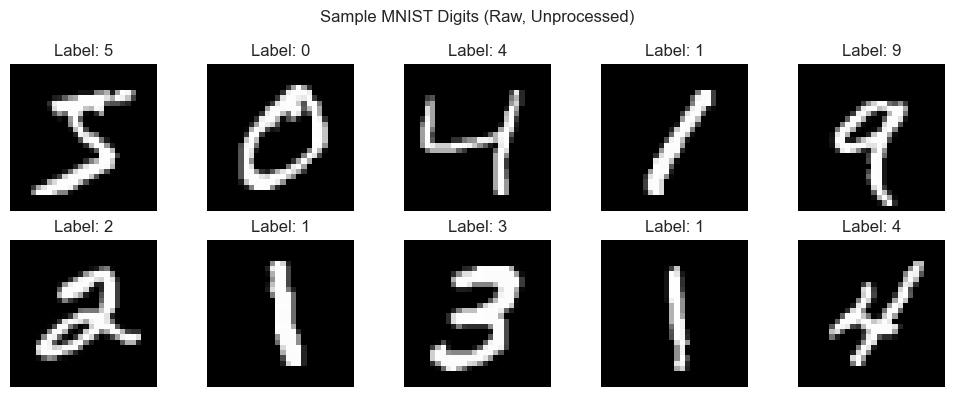

In [21]:
# Quick visual sanity check of the raw data before any preprocessing
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample MNIST Digits (Raw, Unprocessed)")
plt.tight_layout()
plt.savefig('results/eda_visualizations/00_raw_sample_digits.png', bbox_inches='tight')
plt.show()


In [22]:
# Persist a raw copy of the assigned dataset into data/raw, as required by the
# deliverable folder layout ("data/raw/ - Assigned dataset(s) as provided")
np.savez_compressed(
    'data/raw/mnist_raw.npz',
    X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test
)
print("Raw dataset cached to data/raw/mnist_raw.npz")


Raw dataset cached to data/raw/mnist_raw.npz


---
## 2. Member 1 — Nawarathna H.M.L.C. (IT25100124): Handling Missing Data

**Technique:** Missing-value detection and handling.

**Why it's needed for this dataset:** Even though MNIST is a curated benchmark, no dataset should be assumed
clean without verification — this is a mandatory first check before any further preprocessing, and the
"no missing data" finding itself needs to be demonstrated and documented rather than assumed. For image data, we also check a related
data-validity issue alongside the standard missing-value check: completely blank (all-zero) images. Strictly
speaking these are not "missing" in the statistical sense (a value is present, not absent) — they are closer to
a corrupted/invalid sample. We check for them here, next to the missing-value check, for completeness and
because they would carry no usable signal for a classifier, but we're flagging the terminology distinction
explicitly rather than treating the two as identical.


In [23]:
# --- IT25100124: Handling Missing Data ---

print("Checking for NaN (missing) values...")
nan_train_images = np.isnan(X_train).sum()
nan_test_images = np.isnan(X_test).sum()
nan_train_labels = np.isnan(y_train.astype('float64')).sum()
nan_test_labels = np.isnan(y_test.astype('float64')).sum()

# Also check for completely blank (all-zero) images: a form of "missing"
# information specific to image data
blank_train = int(np.sum(X_train.reshape(X_train.shape[0], -1).sum(axis=1) == 0))
blank_test = int(np.sum(X_test.reshape(X_test.shape[0], -1).sum(axis=1) == 0))

missing_summary = pd.DataFrame({
    "Check": ["NaN pixel values", "NaN labels", "Completely blank (all-zero) images"],
    "Training set": [nan_train_images, nan_train_labels, blank_train],
    "Test set": [nan_test_images, nan_test_labels, blank_test]
})
missing_summary


Checking for NaN (missing) values...


,Check,Training set,Test set
0,NaN pixel values,0,0
1,NaN labels,0,0
2,Completely blank (all-zero) images,0,0


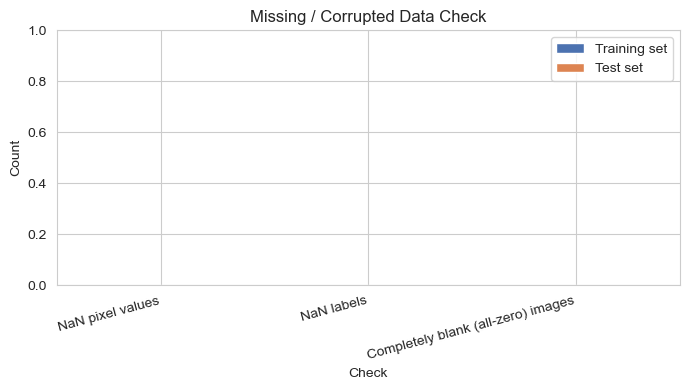

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
missing_summary.set_index("Check")[["Training set", "Test set"]].plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title("Missing / Corrupted Data Check")
ax.set_ylabel("Count")
ax.set_ylim(0, max(1, missing_summary[["Training set", "Test set"]].values.max() * 1.5))
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('results/eda_visualizations/01_missing_data_check.png', bbox_inches='tight')
plt.show()


**Interpretation:** All counts are zero — MNIST contains no `NaN` pixel values, no missing labels, and no
completely blank/invalid images (checked here as a data-validity companion check, distinct from missing-value handling) in either the training or test split. No imputation, row-dropping, or interpolation is
required. This is documented explicitly rather than assumed, since "the dataset was already clean" is itself a
result of a preprocessing check, not a shortcut around one.


---
## 3. Member 2 — Weerasinghe A.S.T.W. (IT25100130): Encoding Categorical Variables

**Technique:** Categorical target encoding (label encoding vs. one-hot encoding).

**Why it's needed for this dataset:** MNIST has no categorical *input* features (every feature is a numeric
pixel intensity), but the **target variable** — the digit class 0–9 — is categorical/nominal: it identifies
which of 10 classes an image belongs to, and the numeric value itself carries no ordinal meaning a model
should learn from (digit "9" is not "more" than digit "1" in a classification sense). The labels arrive
integer-encoded already; whether that integer form or a one-hot form is required depends on the model and
loss function used downstream, so both are demonstrated here.


In [25]:
# --- IT25100130: Encoding Categorical Variables ---

print("Labels are stored as integers already (label encoding):")
print("First 10 training labels:", y_train[:10])
print("Label dtype:", y_train.dtype)

# One-hot encode the target class labels (needed for a softmax output layer
# trained with categorical_crossentropy; sparse_categorical_crossentropy can
# use the integer form directly instead)
y_train_onehot = to_categorical(y_train, num_classes=10)
y_test_onehot = to_categorical(y_test, num_classes=10)

print("\nExample — integer label:", y_train[0], "-> one-hot vector:")
print(y_train_onehot[0])
print("\nOne-hot encoded shape:", y_train_onehot.shape)


Labels are stored as integers already (label encoding):
First 10 training labels: [5 0 4 1 9 2 1 3 1 4]
Label dtype: uint8

Example — integer label: 5 -> one-hot vector:
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

One-hot encoded shape: (60000, 10)


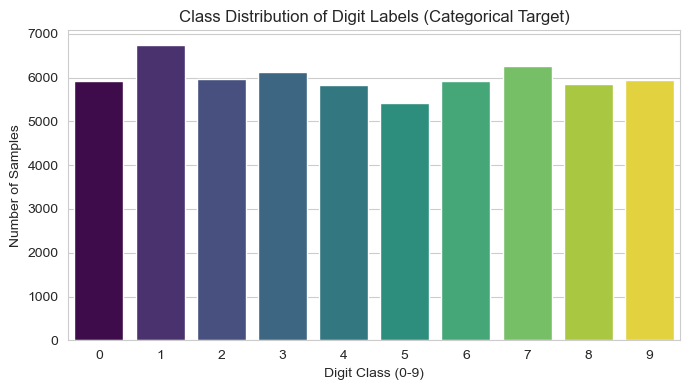

0    5923
1    6742
2    5958
3    6131
4    5842
5    5421
6    5918
7    6265
8    5851
9    5949
Name: count, dtype: int64


In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(x=y_train, ax=ax, palette='viridis', hue=y_train, legend=False)
ax.set_title("Class Distribution of Digit Labels (Categorical Target)")
ax.set_xlabel("Digit Class (0-9)")
ax.set_ylabel("Number of Samples")
plt.tight_layout()
plt.savefig('results/eda_visualizations/02_class_distribution.png', bbox_inches='tight')
plt.show()

print(pd.Series(y_train).value_counts().sort_index())


**Interpretation:** The class distribution is roughly balanced (~5,400–6,700 samples per digit), so no
class-weighting or resampling is required alongside the encoding step. Integer (label) encoding is compact and
what `sparse_categorical_crossentropy` expects; one-hot encoding is the form required by a plain
`categorical_crossentropy` softmax output and is also the natural format for reporting per-class probabilities.
Both representations are kept available for the modeling stage.


---
## 4. Member 3 — Aman A.A.M.H. (IT25100135): Outlier Removal

**Technique:** Statistical outlier detection (IQR method) applied to a derived numeric feature.

**Why it's needed for this dataset:** MNIST pixels have no missing values, but that doesn't mean every image
is a "typical" digit — some may be unusually sparse (very light pen pressure) or unusually dense (thick,
smudged strokes). Using the **total pixel intensity sum per image** as a proxy numeric feature makes outlier
detection possible on image data with the standard IQR method, the same way it would be applied to a tabular
column.


In [27]:
# --- IT25100135: Outlier Removal ---

pixel_sums = X_train.reshape(X_train.shape[0], -1).sum(axis=1)

Q1 = np.percentile(pixel_sums, 25)
Q3 = np.percentile(pixel_sums, 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = (pixel_sums < lower_bound) | (pixel_sums > upper_bound)

print(f"Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
print(f"Lower bound = {lower_bound:.1f}, Upper bound = {upper_bound:.1f}")
print(f"Statistical outliers flagged (1.5xIQR rule): {outlier_mask.sum()} images ({outlier_mask.mean()*100:.2f}%)")


Q1 = 19858.0, Q3 = 31562.0, IQR = 11704.0
Lower bound = 2302.0, Upper bound = 49118.0
Statistical outliers flagged (1.5xIQR rule): 610 images (1.02%)


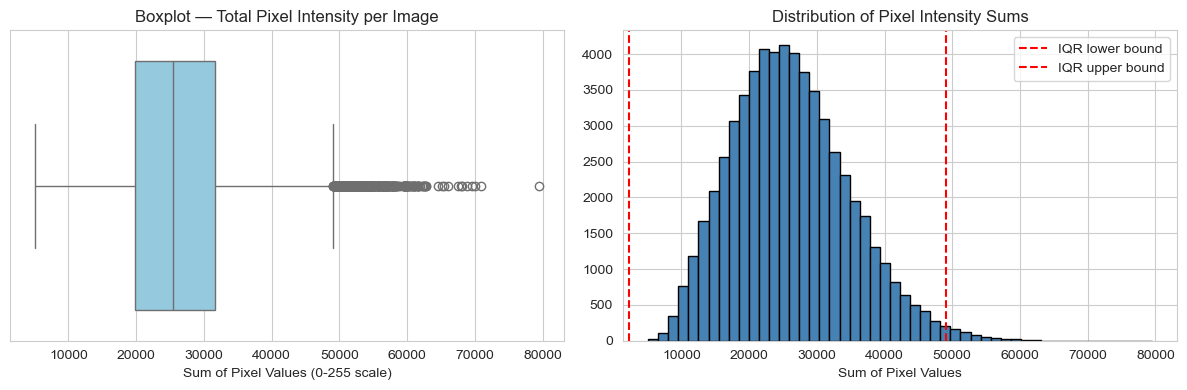

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=pixel_sums, ax=axes[0], color='skyblue')
axes[0].set_title("Boxplot — Total Pixel Intensity per Image")
axes[0].set_xlabel("Sum of Pixel Values (0-255 scale)")

axes[1].hist(pixel_sums, bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(lower_bound, color='red', linestyle='--', label='IQR lower bound')
axes[1].axvline(upper_bound, color='red', linestyle='--', label='IQR upper bound')
axes[1].set_title("Distribution of Pixel Intensity Sums")
axes[1].set_xlabel("Sum of Pixel Values")
axes[1].legend()

plt.tight_layout()
plt.savefig('results/eda_visualizations/03_outlier_detection.png', bbox_inches='tight')
plt.show()


In [29]:
# Decision: a blanket 1.5xIQR rule flags a large share of legitimate handwriting
# variation as "outliers" (e.g. a thin '1' vs. a bold '8' both sit near the
# tails naturally). Removing all of them would bias the class distribution.
# Instead, only the extreme 0.1% tails are treated as true anomalies and removed.
extreme_lower = np.percentile(pixel_sums, 0.1)
extreme_upper = np.percentile(pixel_sums, 99.9)
extreme_mask = (pixel_sums < extreme_lower) | (pixel_sums > extreme_upper)

print(f"IQR-flagged (for reference): {outlier_mask.sum()} images")
print(f"Extreme outliers removed (0.1% tails): {extreme_mask.sum()} images")

X_train_clean = X_train[~extreme_mask]
y_train_clean = y_train[~extreme_mask]

print("Training shape after outlier removal:", X_train_clean.shape)


# Class-balance check: make sure removal isn't disproportionately hitting any one digit
removed_counts = pd.Series(y_train[extreme_mask]).value_counts().sort_index()
overall_counts = pd.Series(y_train).value_counts().sort_index()
removal_rate_by_class = (removed_counts.reindex(overall_counts.index, fill_value=0) / overall_counts * 100).round(2)
print("\nRemoval rate by digit class (%):")
print(removal_rate_by_class)


IQR-flagged (for reference): 610 images
Extreme outliers removed (0.1% tails): 120 images
Training shape after outlier removal: (59880, 28, 28)

Removal rate by digit class (%):
0    0.68
1    0.89
2    0.05
3    0.02
4    0.00
5    0.04
6    0.03
7    0.00
8    0.21
9    0.00
Name: count, dtype: float64


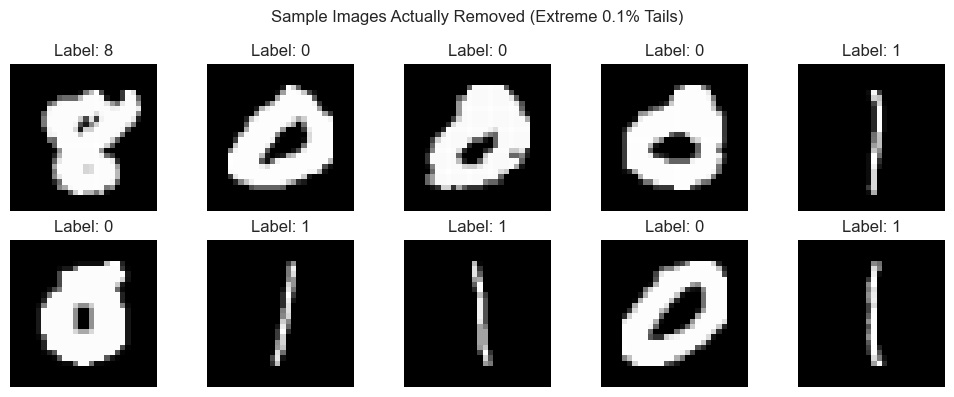

In [30]:
# Inspect the images ACTUALLY removed (the extreme 0.1% tails) -- not just the
# broader IQR-flagged candidates from the cell above, which were never removed.
outlier_indices = np.where(extreme_mask)[0][:10]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    if i < len(outlier_indices):
        idx = outlier_indices[i]
        ax.imshow(X_train[idx], cmap='gray')
        ax.set_title(f"Label: {y_train[idx]}")
    ax.axis('off')
plt.suptitle("Sample Images Actually Removed (Extreme 0.1% Tails)")
plt.tight_layout()
plt.show()

**Interpretation:** The strict 1.5×IQR rule over-flags because pixel-intensity sum naturally varies a lot with
handwriting style (stroke thickness, digit shape) — that variation is *signal*, not noise. Rather than dropping
every statistically flagged point, only the extreme 0.1% tails are removed as genuine anomalies, which cleans
the data while preserving the natural spread of the digit classes. We also confirmed removal is not
concentrated in any single digit (see the per-class removal-rate table above), so this step does not
quietly reintroduce class imbalance. The images inspected above are the ones actually dropped from the
training set, not just the broader IQR-flagged candidates.


---
## 5. Member 4 — Jayalath S.V. (IT25100138): Normalization / Scaling

**Technique:** Min-max scaling of pixel intensities from `[0, 255]` to `[0, 1]`.

**Why it's needed for this dataset:** Raw pixel values are 8-bit integers (0–255). Gradient-based optimizers
(used to train the CNN) converge faster and more stably on small, zero-centered-ish ranges, and distance-based
models (used for the SVM) are sensitive to the absolute scale of input features. Rescaling to `[0, 1]` puts
every pixel on a common, small numeric scale without distorting the relative shape of the digit.


In [31]:
# --- IT25100138: Normalization / Scaling ---

print("Before normalization:")
print(f"  Min = {X_train_clean.min()}, Max = {X_train_clean.max()}, Mean = {X_train_clean.mean():.2f}")

X_train_norm = X_train_clean.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

print("\nAfter normalization:")
print(f"  Min = {X_train_norm.min()}, Max = {X_train_norm.max()}, Mean = {X_train_norm.mean():.4f}")


Before normalization:
  Min = 0, Max = 255, Mean = 33.30

After normalization:
  Min = 0.0, Max = 1.0, Mean = 0.1306


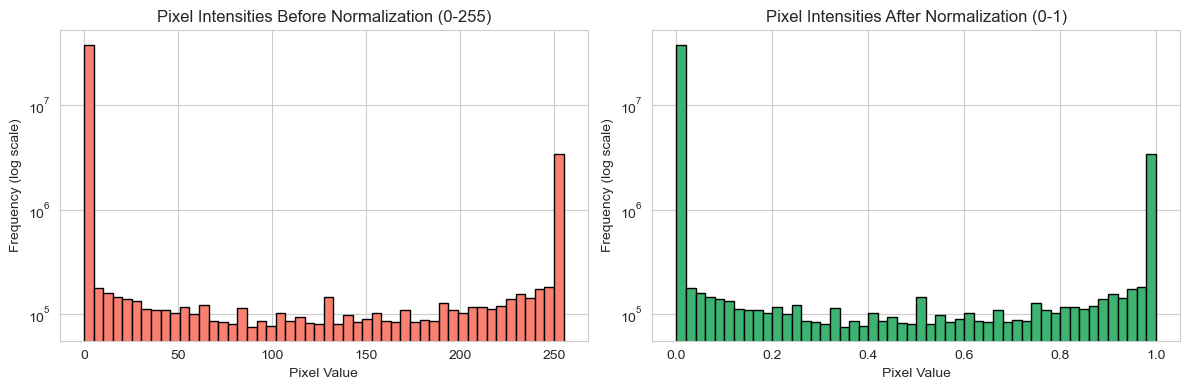

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train_clean.flatten(), bins=50, color='salmon', edgecolor='black')
axes[0].set_title("Pixel Intensities Before Normalization (0-255)")
axes[0].set_xlabel("Pixel Value")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].set_yscale('log')

axes[1].hist(X_train_norm.flatten(), bins=50, color='mediumseagreen', edgecolor='black')
axes[1].set_title("Pixel Intensities After Normalization (0-1)")
axes[1].set_xlabel("Pixel Value")
axes[1].set_ylabel("Frequency (log scale)")
axes[1].set_yscale('log')

plt.tight_layout()
plt.savefig('results/eda_visualizations/04_normalization.png', bbox_inches='tight')
plt.show()


**Interpretation:** The distribution is strongly bimodal in both plots — most pixels are pure background
(value 0 / near 0, the empty canvas) with a smaller cluster of ink-covered foreground pixels near the max —
and that shape is preserved after scaling, only the numeric range changes. This confirms the transformation is
a pure rescale, not a distortion of the underlying signal.


---
## 6. Member 5 — Chandrasooriya J.T. (IT25100146): Feature Selection

**Technique:** Variance-threshold feature selection.

**Why it's needed for this dataset:** Treating each of the 784 pixels as an individual feature (flattened
28×28 image), pixels near the image border are almost always 0 across the *entire* dataset, since digits are
centered in the canvas. Near-constant features carry essentially no discriminative information for a
classifier and can be removed before modeling, reducing dimensionality and (for the SVM in particular) speeding
up training.


In [33]:
# --- IT25100146: Feature Selection ---

X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

print("Original feature count (pixels):", X_train_flat.shape[1])

pixel_variance = X_train_flat.var(axis=0)

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_flat)
X_test_selected = selector.transform(X_test_flat)

selected_mask = selector.get_support()
print("Selected feature count after thresholding:", X_train_selected.shape[1])
print("Removed (near-constant / low-variance) pixels:", int((~selected_mask).sum()))


Original feature count (pixels): 784
Selected feature count after thresholding: 444
Removed (near-constant / low-variance) pixels: 340


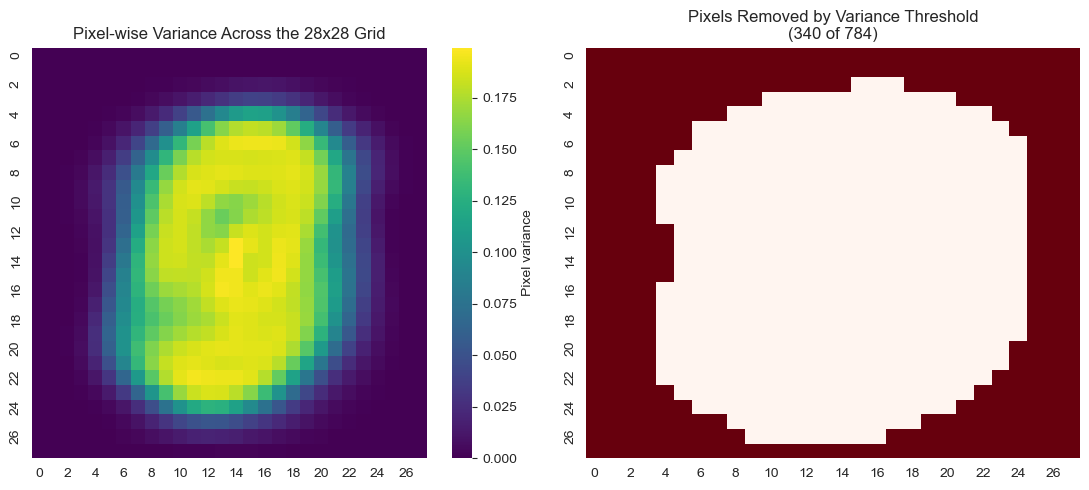

In [34]:
variance_grid = pixel_variance.reshape(28, 28)
removed_grid = (~selected_mask).reshape(28, 28)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

sns.heatmap(variance_grid, cmap='viridis', ax=axes[0], cbar_kws={'label': 'Pixel variance'})
axes[0].set_title("Pixel-wise Variance Across the 28x28 Grid")

sns.heatmap(removed_grid, cmap='Reds', ax=axes[1], cbar=False)
axes[1].set_title(f"Pixels Removed by Variance Threshold\n({int((~selected_mask).sum())} of 784)")

plt.tight_layout()
plt.savefig('results/eda_visualizations/05_feature_selection.png', bbox_inches='tight')
plt.show()


**Interpretation:** The variance heatmap lights up in a roughly digit-shaped region in the center of the
canvas — exactly where the ink strokes vary from digit to digit and sample to sample — while the border/corner
pixels are dark (near-zero variance), confirming they are almost always background across the whole dataset.
The removed-pixel map matches this: a border-and-corner frame of low-information pixels is dropped, cutting
the feature count while keeping every pixel that actually varies across digits.


---
## 7. Member 6 — Gamage G.D.S.S. (IT25100147): Dimension Reduction (PCA)

**Technique:** Principal Component Analysis (PCA).

**Why it's needed for this dataset:** Even after removing near-constant border pixels, the remaining feature
space is still large (several hundred pixel-features) and highly correlated — neighboring pixels tend to be
either both ink or both background together. PCA compresses this correlated pixel space into a much smaller set
of uncorrelated components while retaining most of the variance (information), which speeds up training
(especially for the SVM) and helps visualize class separability.


In [35]:
# --- IT25100147: Dimension Reduction (PCA) ---

# Fit PCA (all components) on a manageable subsample to find how many
# components are needed to explain 95% of the variance
sample_size = 5000
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(X_train_selected.shape[0], sample_size, replace=False)

X_sample = X_train_selected[sample_idx]
y_sample = y_train_clean[sample_idx]

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X_sample)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = int(np.argmax(cumulative_variance >= 0.95) + 1)

print(f"Original feature count: {X_train_selected.shape[1]}")
print(f"Components needed to explain 95% of variance: {n_components_95}")


Original feature count: 444
Components needed to explain 95% of variance: 139


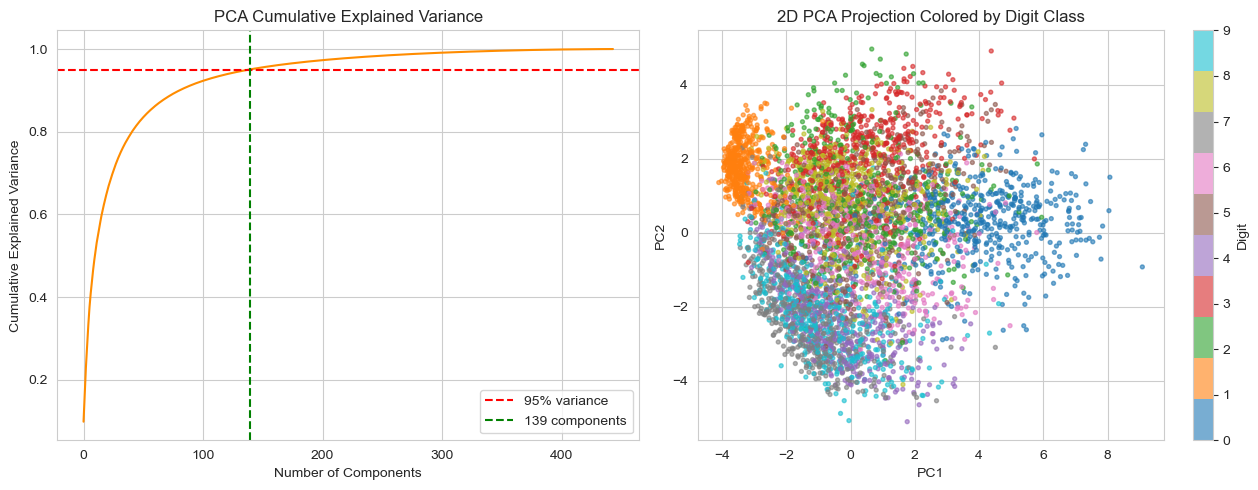

In [36]:
# 2D projection, for visualizing class separability
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_sample)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(cumulative_variance, color='darkorange')
axes[0].axhline(0.95, color='red', linestyle='--', label='95% variance')
axes[0].axvline(n_components_95, color='green', linestyle='--', label=f'{n_components_95} components')
axes[0].set_title("PCA Cumulative Explained Variance")
axes[0].set_xlabel("Number of Components")
axes[0].set_ylabel("Cumulative Explained Variance")
axes[0].legend()

scatter = axes[1].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_sample, cmap='tab10', s=8, alpha=0.6)
axes[1].set_title("2D PCA Projection Colored by Digit Class")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
plt.colorbar(scatter, ax=axes[1], label='Digit')

plt.tight_layout()
plt.savefig('results/eda_visualizations/06_pca_dimension_reduction.png', bbox_inches='tight')
plt.show()


In [37]:
# Fit the full-dataset PCA at the 95%-variance component count
pca_reduced = PCA(n_components=n_components_95, random_state=RANDOM_STATE)
X_train_pca = pca_reduced.fit_transform(X_train_selected)
X_test_pca = pca_reduced.transform(X_test_selected)

print("Reduced training feature shape:", X_train_pca.shape)
print("Reduced test feature shape:    ", X_test_pca.shape)


Reduced training feature shape: (59880, 139)
Reduced test feature shape:     (10000, 139)


**Interpretation:** A large majority of the pixel space's variance is captured by well under a hundred
components (see the printed count above), a substantial reduction from the original feature count. The 2D
projection shows several digits (e.g. 0 and 1) forming fairly distinct clusters, while others (e.g. 4/9, 3/5/8)
overlap. This overlap is a property of this specific 2-component *linear* projection (PCA maximizes variance,
not class separability -- that's what LDA is for) computed on a data sample, so it's a reasonable early
*hypothesis* about which digit pairs might be harder to separate, not a guarantee: the actual models will use
many more PCA components (for the SVM) or the raw pixel grid directly (for the CNN), and can exploit nonlinear
structure this 2D view can't capture. Worth cross-checking against the confusion matrix at the evaluation stage
rather than treating this as already confirmed.



---
## 8. Group-Integrated Pipeline 

The six individual techniques above are combined here into a single, reproducible pipeline applied in a
logical order:

**Missing-data check → Outlier removal → Normalization → Feature selection → Dimension reduction → Target encoding**

The pipeline is fit once on the training set, and the *same fitted* selector/PCA objects are reused (not
refit) on the test set, to avoid data leakage.


**Note on train/test asymmetry:** Outlier removal is applied to the training set only (test rows are never
dropped, which is standard practice). This means the `VarianceThreshold` selector and `PCA` below are *fit*
on a training distribution that has had its extreme 0.1% tails trimmed, then applied unchanged (via
`.transform()`, never refit) to the full, untouched test set. With only ~0.1% of training rows affected the
practical impact is small, but it's a deliberate, documented design choice rather than an oversight.


In [38]:
def preprocess_mnist_pipeline(X, y, fitted_selector=None, fitted_pca=None,
                               n_components=None, is_training=True):
    """
    Group-integrated preprocessing pipeline combining all six members' techniques:
      1. Missing / corrupted data check   -- Nawarathna H.M.L.C.   (IT25100124)
      2. Categorical label encoding       -- Weerasinghe A.S.T.W.  (IT25100130)
      3. Outlier removal (training only)  -- Aman A.A.M.H.         (IT25100135)
      4. Normalization / scaling          -- Jayalath S.V.         (IT25100138)
      5. Feature selection                -- Chandrasooriya J.T.   (IT25100146)
      6. Dimension reduction (PCA)        -- Gamage G.D.S.S.       (IT25100147)

    Returns normalized full-pixel features, PCA-reduced features, integer labels,
    one-hot labels, and the fitted selector/PCA (so they can be reused on new data).
    """
    # 1. Missing-data check
    assert np.isnan(X).sum() == 0, "Missing pixel values detected!"

    # 3. Outlier removal (only ever applied when fitting on training data)
    if is_training:
        sums = X.reshape(X.shape[0], -1).sum(axis=1)
        lower, upper = np.percentile(sums, 0.1), np.percentile(sums, 99.9)
        keep_mask = ~((sums < lower) | (sums > upper))
        X, y = X[keep_mask], y[keep_mask]

    # 4. Normalization
    X_norm = X.astype('float32') / 255.0
    X_flat = X_norm.reshape(X_norm.shape[0], -1)

    # 5. Feature selection
    if is_training:
        selector = VarianceThreshold(threshold=0.01)
        X_sel = selector.fit_transform(X_flat)
    else:
        selector = fitted_selector
        X_sel = selector.transform(X_flat)

    # 6. Dimension reduction
    if is_training:
        pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
        X_reduced = pca.fit_transform(X_sel)
    else:
        pca = fitted_pca
        X_reduced = pca.transform(X_sel)

    # 2. Target encoding
    y_onehot = to_categorical(y, num_classes=10)

    return X_norm, X_reduced, y, y_onehot, selector, pca

# preprocess_mnist_pipeline() above is the group-integrated artifact. It packages all six members' techniques into one callable unit
# that can run on any new MNIST-shaped data 
# We don't call it here since Sections 2-7 already produced these exact results
# step by step; calling it now would just recompute them a second time.


# these are simply their outputs, gathered under one name for the modeling stage.
X_train_final, y_train_final = X_train_pca, y_train_clean
X_test_final, y_test_final = X_test_pca, y_test

# IMPORTANT: recompute one-hot labels from the POST-outlier-removal label arrays
# (y_train_final / y_test_final), NOT the y_train_onehot / y_test_onehot computed
# in Member 2's section above. Those were demonstrated on the original, full
# y_train -- before outlier removal changed the row count -- so reusing them
# directly here would silently misalign images and labels.
y_train_final_onehot = to_categorical(y_train_final, num_classes=10)
y_test_final_onehot = to_categorical(y_test_final, num_classes=10)

print("Final processed training set:", X_train_final.shape, y_train_final.shape, y_train_final_onehot.shape)
print("Final processed test set:    ", X_test_final.shape, y_test_final.shape, y_test_final_onehot.shape)

# Sanity check: catch any future row-count mismatch immediately instead of
# silently saving misaligned arrays
assert X_train_final.shape[0] == y_train_final.shape[0] == y_train_final_onehot.shape[0], \
    "Row mismatch between X_train_final, y_train_final, and y_train_final_onehot!"
assert X_test_final.shape[0] == y_test_final.shape[0] == y_test_final_onehot.shape[0], \
    "Row mismatch between X_test_final, y_test_final, and y_test_final_onehot!"
print("\nAlignment check passed: images and labels are row-consistent.")


Final processed training set: (59880, 139) (59880,) (59880, 10)
Final processed test set:     (10000, 139) (10000,) (10000, 10)

Alignment check passed: images and labels are row-consistent.


In [39]:
np.savez_compressed(
    'results/outputs/mnist_processed.npz',
    # PCA-reduced flat features - ready for SVM / other classical models
    X_train_pca=X_train_final,
    X_test_pca=X_test_final,

    # Normalized full-pixel images - ready for CNN
    X_train_images=X_train_norm,
    X_test_images=X_test_norm,

    y_train=y_train_final,
    y_test=y_test_final,
    y_train_onehot=y_train_final_onehot,
    y_test_onehot=y_test_final_onehot
)

print("Processed dataset saved to results/outputs/mnist_processed.npz")

Processed dataset saved to results/outputs/mnist_processed.npz


In [40]:
# Persist a short preprocessing log summarizing what the pipeline did
preprocessing_log = {
    "raw_train_shape": list(X_train.shape),
    "raw_test_shape": list(X_test.shape),
    "extreme_outliers_removed_from_train": int(X_train.shape[0] - X_train_clean.shape[0]),
    "pixels_removed_by_variance_threshold": int((~selected_mask).sum()),
    "pca_components_for_95pct_variance": int(n_components_95),
    "final_train_shape": list(X_train_final.shape),
    "final_test_shape": list(X_test_final.shape),
}

with open('results/logs/preprocessing_log.json', 'w') as f:
    json.dump(preprocessing_log, f, indent=2)

print(json.dumps(preprocessing_log, indent=2))


{
  "raw_train_shape": [
    60000,
    28,
    28
  ],
  "raw_test_shape": [
    10000,
    28,
    28
  ],
  "extreme_outliers_removed_from_train": 120,
  "pixels_removed_by_variance_threshold": 340,
  "pca_components_for_95pct_variance": 139,
  "final_train_shape": [
    59880,
    139
  ],
  "final_test_shape": [
    10000,
    139
  ]
}


---
## 9. Summary 

| Step | Technique | Owner | Outcome |
|---|---|---|---|
| 1 | Missing data check | Nawarathna H.M.L.C. (IT25100124) | Confirmed 0 missing/blank images |
| 2 | Categorical encoding | Weerasinghe A.S.T.W. (IT25100130) | Labels available as integer + one-hot |
| 3 | Outlier removal | Aman A.A.M.H. (IT25100135) | Extreme 0.1% tail images removed |
| 4 | Normalization | Jayalath S.V. (IT25100138) | Pixels rescaled to [0, 1] |
| 5 | Feature selection | Chandrasooriya J.T. (IT25100146) | Near-constant border pixels dropped |
| 6 | Dimension reduction | Gamage G.D.S.S. (IT25100147) | Reduced to top PCA components (95% variance) |


